# ARGUS-FEDER — Answering GA's disruption competency questions

General Atomics maintains a set of 27 competency questions for DIII-D data,
split into an ELM half and a disruption half. This notebook works through the
**disruption half, Q14–Q27**, against a stored disruption index built from
`disruption-py` output.

Each question is tagged with what the index can actually deliver: answerable
now, answerable for one pipeline only, or correctly refused.

## The one thing to keep in mind

GA's questions are written for **three** disruption pipelines. We have run
**one** — `disruption-py`, the public MIT-PSFC code. Questions that ask for
agreement *across* pipelines cannot be answered yet, and the correct response
is to say which pipeline was used and what is missing, not to answer as though
one pipeline were all of them.

The index also holds **20 shots, balanced 10 disrupted / 10 not**. It is a
demonstration slice, not a sample of the archive. Any question phrased as a
rate or a fraction is unanswerable from it by construction.

In [ ]:
%reset

---
# A. Answerable now, from this index

## Q20 — Which pipeline produced a label, at what version, from which inputs?

*provenance · **answerable***

Provenance is answerable by construction once a pipeline is run and what was
run is recorded alongside the labels it produced.

In [2]:
%%ask --review
For the disruption labels in the index: which code produced them, at what
version and commit, when was it run and by whom, and what were its inputs? Show
me the full provenance record.

I'll look up the provenance metadata stored alongside the disruption index. Let me plan this first.

Reading the skill instructions to locate the provenance metadata.

The skill documents `index_info()` as the provenance call, returning producing code pinned to a commit from the NetCDF global attributes. Now querying the actual index for the full record.

Running the provenance query against the index.

Clean run — I have the complete record. Marking the work complete.

Here is the full provenance record for the disruption labels, as stored in the index and returned verbatim by `index_info()`:

## Producing code

| Field | Value |
|---|---|
| **Package** | `disruption_py` |
| **Version** | 0.15.0.dev0 |
| **Commit SHA** | `9987784e78ef9736e2fe42142683b3458ff38d8d` |
| **Source URL** | https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d |
| **Tokamak** | D3D |

## Run record

| Field | Value |
|---|---|
| **Produced by** | `sammuli` |
| **Produced on** | `omega06.gat.com` |
| **Produced at** | 2026-08-19T07:36:50.648611 |
| **Ingested into this index at** | 2026-08-19T20:46:49+00:00 |
| **Source file** | `d3d_disruption_example.nc` |

## Inputs and what produced *the labels specifically*

The index holds **two** disruption-related labels, and they have different provenance:

- **`time_until_disrupt` — the authoritative label.** Sourced from the **human-curated `disruptions` table in d3drdb** (DIII-D's relational database), not from disruption-py's algorithms. Every `disruption_label()` call carries `source: "time_until_disrupt (d3drdb, curated)"`.
- **`current_quench_time` — the derived label.** disruption-py's own estimate from the plasma-current decay, at the version/commit above. It disagrees with the curated label on 3 of the 20 indexed shots (198244, 198643, 199062 — curated says not-disrupted, derived says disrupted). The curated label wins in all reporting.

So the chain is: **d3drdb curated disruptions table → disruption-py 0.15.0.dev0 (commit `9987784e…`, run by sammuli on omega06.gat.com, 2026-08-19T07:36:50) → `d3d_disruption_example.nc` → this sqlite index (ingested 2026-08-19T20:46:49 UTC)** . The 63 physics parameters alongside the labels were produced by disruption-py's 14 `get_*` methods over DIII-D shot data for shots 194000–199687.

## Coverage caveat (required when quoting this index)

**Coverage note** : 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

## Q15 — Which quantities are disruption precursors, and what measures each?

*precursor map · **answerable***

The assessment noted that `disruption-py`'s feature set *is* the precursor
map — n=1 mode amplitude, betap, li, q95, radiated fraction, locked mode,
v_loop. Now that it has been run, that map is queryable with units attached.

In [3]:
%%ask --review
Which quantities in this dataset are disruption precursors, and what does
each one measure? Group them by the physics method that produces them, and give
the units for each.

Reading the skill instructions to find how parameter metadata is exposed.

The skill confirms the parameter dictionary (`parameter_info`, `parameters`) is the authoritative source for meanings, methods, and units. Now querying the full parameter catalog.

Catalog retrieved — 63 parameters across 14 physics-method groups. Marking the remaining steps done and writing the report.

All 63 quantities in the index, grouped by the disruption-py physics method that produces each one. 60 of them are usable precursor channels; 3 are blocked by upstream defects; and the "Labels and shot phase" group contains the outcome labels themselves rather than precursors.

## Equilibrium reconstruction — `get_efit_parameters` (offline EFIT)

| Parameter | Measures | Units |
|---|---|---|
| `beta_n` | Normalised beta | % m T MA⁻¹ |
| `beta_p` | Poloidal beta | 1 |
| `chisq` | EFIT fit quality | 1 |
| `dbetap_dt` | d(beta_p)/dt | s⁻¹ |
| `dli_dt` | d(li)/dt | s⁻¹ |
| `dwmhd_dt` | d(wmhd)/dt | W |
| `kappa` | Elongation | 1 |
| `li` | Internal inductance | 1 |
| `lower_gap` | Gap, plasma to lower wall | m |
| `q0` | Safety factor on axis | 1 |
| `q95` | Safety factor at 95% flux surface | 1 |
| `qstar` | Cylindrical safety factor | 1 |
| `upper_gap` | Gap, plasma to upper wall | m |
| `wmhd` | Stored magnetic energy | J |

## Real-time equilibrium — `get_rt_efit_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `beta_p_rt` | Poloidal beta (real-time) | 1 |
| `chisq_rt` | Fit quality (real-time) | 1 |
| `li_rt` | Internal inductance (real-time) | 1 |
| `q95_rt` | q95 (real-time) | 1 |
| `wmhd_rt` | Stored energy (real-time) | J |

## Plasma current — `get_ip_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `ip` | Measured plasma current | A |
| `ip_prog` | Programmed plasma current | MA |
| `ip_error` | ip − ip_prog | A — **unusable** (numerically identical to `ip`; `ip_prog` in MA used unscaled) |
| `dip_dt` | d(ip)/dt | A s⁻¹ |
| `dipprog_dt` | d(ip_prog)/dt | MA s⁻¹ — **unusable** (MA/s vs. A/s twin; use `dipprog_dt_rt`) |

## Real-time plasma current — `get_rt_ip_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `ip_rt` | Measured plasma current (real-time) | A |
| `ip_prog_rt` | Programmed current (real-time) | A |
| `ip_error_rt` | Current error (real-time) | A |
| `dip_dt_rt` | d(ip)/dt (real-time) | A s⁻¹ |
| `dipprog_dt_rt` | d(ip_prog)/dt (real-time) | A s⁻¹ |

## Line-averaged density — `get_density_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `n_e` | Line-averaged electron density | m⁻³ |
| `greenwald_fraction` | n_e / Greenwald density limit | 1 |
| `dn_dt` | d(n_e)/dt | m⁻³ s⁻¹ |

## Real-time density — `get_rt_density_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `n_e_rt` | Electron density (real-time) | m⁻³ |
| `greenwald_fraction_rt` | Greenwald fraction (real-time) | 1 |
| `dn_dt_rt` | d(n_e)/dt (real-time) | m⁻³ s⁻¹ |

## MHD modes — `get_n1_bradial_parameters` / `get_n1rms_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `n1rms` | n=1 RMS amplitude | T |
| `n1rms_normalized` | n=1 RMS normalised by toroidal field | 1 |
| `n_equal_1_mode` | n=1 radial field amplitude | T |
| `n_equal_1_normalized` | n=1 amplitude normalised by toroidal field | 1 |

## Heating and radiation — `get_power_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `p_nbi` | Neutral-beam injected power | W |
| `p_ech` | Electron-cyclotron heating power | W |
| `p_rad` | Radiated power (bolometry, causal 10 ms smoothing) | W |
| `radiated_fraction` | p_rad / total input power | 1 (needs clipping) |

## Ohmic drive — `get_ohmic_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `v_loop` | Loop voltage | V |
| `p_ohm` | Ohmic heating power | W |

## Profile peaking, real-time — `get_peaking_factors`

| Parameter | Measures | Units |
|---|---|---|
| `ne_peaking_cva_rt` | Electron density peaking, core vs. all | 1 |
| `te_peaking_cva_rt` | Electron temperature peaking, core vs. all | 1 |
| `prad_peaking_cva_rt` | Radiated power peaking, core vs. all | 1 |
| `prad_peaking_xdiv_rt` | Radiated power peaking, divertor region | 1 |

## Geometry / shape — `get_shape_parameters` / `get_kappa_area`

| Parameter | Measures | Units |
|---|---|---|
| `aminor` | Minor radius | m |
| `delta` | Triangularity (mean of top and bottom) | 1 |
| `kappa_area` | Elongation from cross-sectional area | 1 |
| `squareness` | Squareness | 1 |

## Vertical position — `get_z_parameters`

| Parameter | Measures | Units |
|---|---|---|
| `zcur` | Vertical position of the current centroid | m |
| `zcur_normalized` | zcur normalised by minor radius | 1 |

## Misc scalars — `get_btor` / `get_h_alpha` / `get_h98` / `get_zeff_parameters` / `get_power_supply_railed`

| Parameter | Measures | Units |
|---|---|---|
| `btor` | Toroidal magnetic field | T |
| `h_alpha` | H-alpha line emission (uncalibrated) | instrument |
| `h98` | H98(y,2) confinement quality factor | 1 |
| `z_eff` | Effective ion charge | 1 |
| `power_supply_railed` | E-coil supplies at their limit (Ip feedback lost) | 0 / 1 |

## Labels and shot phase (outcomes, not precursors)

| Parameter | Measures | Units |
|---|---|---|
| `time_until_disrupt` | Seconds remaining until disruption; NaN if no disruption — **the authoritative label** (d3drdb, curated) | s |
| `current_quench_time` | Ip-decay-derived quench time (disruption-py estimate; disagrees with the label on 3 of 20 shots) | s |
| `time_domain` | Shot phase: 1 ramp-up, 2 flat-top, 3 ramp-down — **unusable** (constant 1.0; flat-top test scales `ip_prog` wrongly) | category |

## Notes

- **Units convention** : `'1'` means dimensionless (26 parameters); every other parameter carries an explicit unit string; none are unknown (37 explicit + 26 dimensionless = 63). `h_alpha` is the only uncalibrated instrument channel.
- **Blocked parameters** : `fetch_samples()` raises on `ip_error`, `dipprog_dt`, and `time_domain` — all three are upstream unit-handling defects in disruption-py at commit `9987784e78ef…` (v0.15.0.dev0) that return plausible-looking but wrong numbers.
- The offline vs. real-time pairs (e.g. `q95` / `q95_rt`, `wmhd` / `wmhd_rt`) exist because the real-time channels are what a live disruption predictor would actually see; the offline EFIT ones are the higher-quality reconstruction.

**Coverage note** : 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D.

## Q19 — For a given shot, what is the label and the time, and do the indicators agree?

*label agreement · **partially answerable***

GA asks whether three pipelines agree. We have one — but that one carries **two
independent disruption indicators**, and they disagree on some shots.

In [4]:
%%ask --review
For DIII-D shot 194128, give me the disruption label and the disruption
time. Then tell me whether the dataset contains more than one disruption
indicator, whether they agree, and on which shots they disagree.

I'll query the disruption index for shot 194128 and compare the two indicators across all shots. Let me plan the steps.

Reading the skill file again to confirm the query API and database location.

Now querying the index for shot 194128's labels and the disagreement list.

Running the query script against the disruption index.

The query succeeded — marking the remaining steps complete and reporting.

## Shot 194128

- **Disruption label** : disrupted (per the authoritative curated label)
- **Disruption time** : **t = 5.6267 s** (5.626669406890869 s, from the human-curated `disruptions` table in d3drdb)

## More than one disruption indicator?

**Yes — exactly two.**

1. **`time_until_disrupt`** — the **authoritative label** , from the human-curated `disruptions` table in d3drdb. A shot is disrupted if this channel is finite; the disruption time is the last finite value.
2. **`current_quench_time`** — disruption-py's **derived indicator** , estimated from the plasma-current (Ip) decay. It requires `derived=True` to fetch, precisely so the class balance can't silently shift.

Both indicators agree on shot 194128: disrupted, t = 5.6267 s from either source.

## Do they agree?

**On 17 of the 20 indexed shots** — 10 agree-disrupted and 7 agree-not-disrupted.

**They disagree on 3 shots** , and in every disagreement the pattern is the same: the derived Ip-decay indicator flags a disruption where the curated table says none occurred:

| Shot | Curated label | Derived indicator | Derived t_quench |
|---|---|---|---|
| 198244 | not disrupted | disrupted | 5.2172 s |
| 198643 | not disrupted | disrupted | 5.0618 s |
| 199062 | not disrupted | disrupted | 6.4290 s |

On all three, `time_until_disrupt` is NaN for every sample (0 finite samples out of 207 / 201 / 254 rows), while `current_quench_time` is finite throughout and reaches its minimum at the times above — i.e., the Ip decay *looks* like a quench, but the human curators did not call it a disruption. In disruption-py's design the curated label wins, so these 3 shots count as **not disrupted** in any class balance (10/20, not 13/20). Physically, a fast ramp-down that mimics a current quench is the likely explanation for the false positives, but the index itself records only the disagreement, not its cause.

**Coverage note** : 20 shots, 10 disrupted. This is a constructed, deliberately balanced slice — not a random sample of DIII-D.

---
# B. Answerable for one pipeline only

## Q14 — What definition of "disruption" does the pipeline implement?

*definition · **one of three pipelines***

In [5]:
%%ask --review
What definition of a disruption, and of the disruption time, does the
pipeline behind these labels use? Where is that definition documented, and how
would I check it? Be clear about which pipeline this is and which ones are
missing.

I'll consult the d3d-disruption skill again to pin down exactly how the disruption definition is encoded and documented, then trace where that definition lives upstream.

The skill points to two label sources and an HTML writeup as the semantic layer. Let me inspect the skill directory and the index's own metadata for the precise definition text.

The label functions confirm the two-source design. Now I need the definition text itself — let me read the rest of the module and check the d3d-relational-db skill, since that covers d3drdb where the curated table lives.

The relational-db skill has a section on disruption labels. Let me read that section for the d3drdb-side definition.

The picture is now clear from both skills. Let me run a short verification in the index to demonstrate the checkable mechanics of the label definition (disrupted ⟺ finite `time_until_disrupt`; t_disrupt from the last finite value).

Running the verification script against the index.

The mechanical definition verified, but `index_info()` has no `source_url` key — the GitHub URL must be constructed from `commit_sha`. Fixing that line and re-running.

The run succeeded. One edit-and-retry cycle occurred (missing `source_url` key), so I'll record that lesson in the skill's Learnings.md before continuing.

I'll run `label_disagreements()` now to compute the disagreement count, shots, and direction before quoting any of them.

## Which pipeline this is

The labels in this index come from **disruption-py** (MIT-PSFC), version **0.15.0.dev0** , commit **`9987784e78ef9736e2fe42142683b3458ff38d8d`** , run by `sammuli` on `omega06.gat.com` at 2026-08-19T07:36:50, over DIII-D shot data. That run's NetCDF output (`d3d_disruption_example.nc`) was then ingested into this sqlite index at 2026-08-19T20:46:49 UTC. Source tree: https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d

But — crucially — **the authoritative disruption label was not computed by disruption-py's algorithms** . disruption-py only *carried it through*.

## The definition the labels use

**Disrupted or not (authoritative):** the human-curated `disruptions` table in **d3drdb** , GA's relational database of record. Operationally, in this index:

- `time_until_disrupt` = seconds remaining until the disruption at each sample; **NaN everywhere if the shot did not disrupt** (stored definition, verbatim from the index: *"Seconds remaining until disruption; NaN if the shot did not disrupt"*, units s, flagged `authoritative = 1`).
- A shot is disrupted ⟺ `time_until_disrupt` has at least one finite sample.
- **t_disrupt** = time + time_until_disrupt at the last finite sample — i.e. the moment the curated table says the disruption occurred.

I verified both mechanics hold exactly for **all 20 shots** in the index (flag ⟺ finite rows; t_disrupt = last-finite time + countdown, agreement < 1 ms).

**The one definition element not in this index:** *what physical criteria the human curators at GA applied* when populating the `disruptions` table (e.g. Ip quench threshold, locked-mode criteria). That is a convention of the d3drdb curation process — GA-internal documentation — and is **not** recorded here. This index records only that the table is human-curated and treated as ground truth.

**Secondary indicator (not the label):** `current_quench_time`, disruption-py's own **derived** estimate from the plasma-current decay (units s, `authoritative = 0`, caveat *"disagrees with the label"*). It exists to be compared against the curated label, not to replace it — running `label_disagreements()` against the current slice returns **3 disagreements** , all in the same direction (derived flags a disruption where curation says none):

| Shot | Curated label | Derived indicator | Direction |
|---|---|---|---|
| 198244 | not disrupted | disrupted | derived flags a disruption where curation says none |
| 198643 | not disrupted | disrupted | derived flags a disruption where curation says none |
| 199062 | not disrupted | disrupted | derived flags a disruption where curation says none |

## Where the definition is documented

| Layer | What it documents | Location |
|---|---|---|
| **This index's annotation layer** | Per-parameter meaning, units, authoritative flag, caveats — the only queryable semantic layer | `parameter_info("time_until_disrupt")`, `parameter_info("current_quench_time")` |
| **The dataset's HTML writeup** | The semantics the index ingested (the NetCDF itself has **zero** metadata — 0 of 65 variables carry units/long_name/description) | The writeup accompanied the source dataset; its content now lives in this index |
| **disruption-py at the pinned commit** | The code that sourced the curated label and computes `current_quench_time` (D3D backend) | https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d |
| **d3drdb `disruptions` table conventions** | The curation criteria — the actual definition of "disruption" behind the label | GA-internal; **not present here** |

## How you would check it

1. **In the index** (reproducible now): `parameter_info("time_until_disrupt")` → the stored definition string and `authoritative: 1`. `disruption_label(194128)` → `source: "time_until_disrupt (d3drdb, curated)"`. `disruption_label(shot, derived=True)` → the Ip-decay estimate with an explicit warning that it is not the label. `label_disagreements()` → 3 rows, shots 198244, 198643 and 199062, each with `curated_disrupted = 0`, `derived_disrupted = 1`.
2. **Mechanically** , as I did: for each shot, select rows where `time_until_disrupt IS NOT NULL`; the shot's `disrupted` flag equals whether that set is non-empty, and `t_disrupt` equals `time + time_until_disrupt` at the last such row. This holds for 20/20 shots.
3. **In the code** : open the pinned commit above and read the D3D backend's label-sourcing and current-quench routines — that is where the curated table is read and the Ip-decay quench time is computed.
4. **Against d3drdb itself** : only at GA — the live `disruptions` table is the system of record (see next section).

## Which pipelines are missing

- **The human curation pipeline (d3drdb `disruptions` table) — the origin of the label — is not queryable here.** The trimmed local d3drdb copy deliberately **excludes** both dedicated label tables (`DISRUPTIONS`, `disruption_warning`), which are legacy and marked "do not use" per GA. So the definition's ultimate source sits entirely outside this environment.
- **`SUMMARIES.t_disrupt` is present in the local d3drdb copy but is NOT a usable label** — its provenance is explicitly unverified, and the relational-db skill instructs against using it for any disruption question.
- **No other label/predictor pipeline is represented.** The index carries exactly two indicators (curated + Ip-decay-derived). Nothing from FRNN, DBM, or any other disruption-warning system is in this dataset.

**Coverage note** : 20 shots, 10 disrupted. This is a constructed, deliberately balanced slice, not a random sample of DIII-D.

## Q22 — Which shots have every input the pipeline requires?

*input availability · **partially answerable***

I'll refresh the skill instructions and its learned-error notes before querying the index.

Skill and learnings loaded. Now I'll inspect the helper module's schema and `_query` so I can aggregate completeness in one pass.

The schema has a `parameters` table plus `shots` and `disruption_samples`. I'll write a completeness audit script that computes non-null fractions per parameter and per-shot breakdowns for the gaps.

Running the completeness audit against the index.

The audit ran clean in one pass. Marking the analysis steps done and compiling the report.

...

The multiline match keeps failing on exact wrapping; I'll append using the section header as the anchor instead.

Lesson recorded. Here is the completeness report.

I'll re-derive the tier counts programmatically from the fill fractions so the four tiers provably sum to 63.

The re-derivation confirms the tier counts: 10 + 14 + 12 + 27 = 63, with the 60 usable / 3 unusable split also reconciling across tiers.

## The pipeline and its output

The producer is **disruption-py 0.15.0.dev0, commit `9987784e78ef9736e2fe42142683b3458ff38d8d`** (D3D backend, run by `sammuli` on omega06.gat.com, 2026-08-19), ingested here from `d3d_disruption_example.nc`. It emits **63 parameters** across 14 physics methods, materialized as **3,778 sample rows over 20 shots** (10 disrupted / 10 not). Three of the 63 are flagged unusable by the index itself (`time_domain`, `ip_error`, `dipprog_dt`) — upstream disruption-py defects, excluded from any fetch.

## Overall completeness


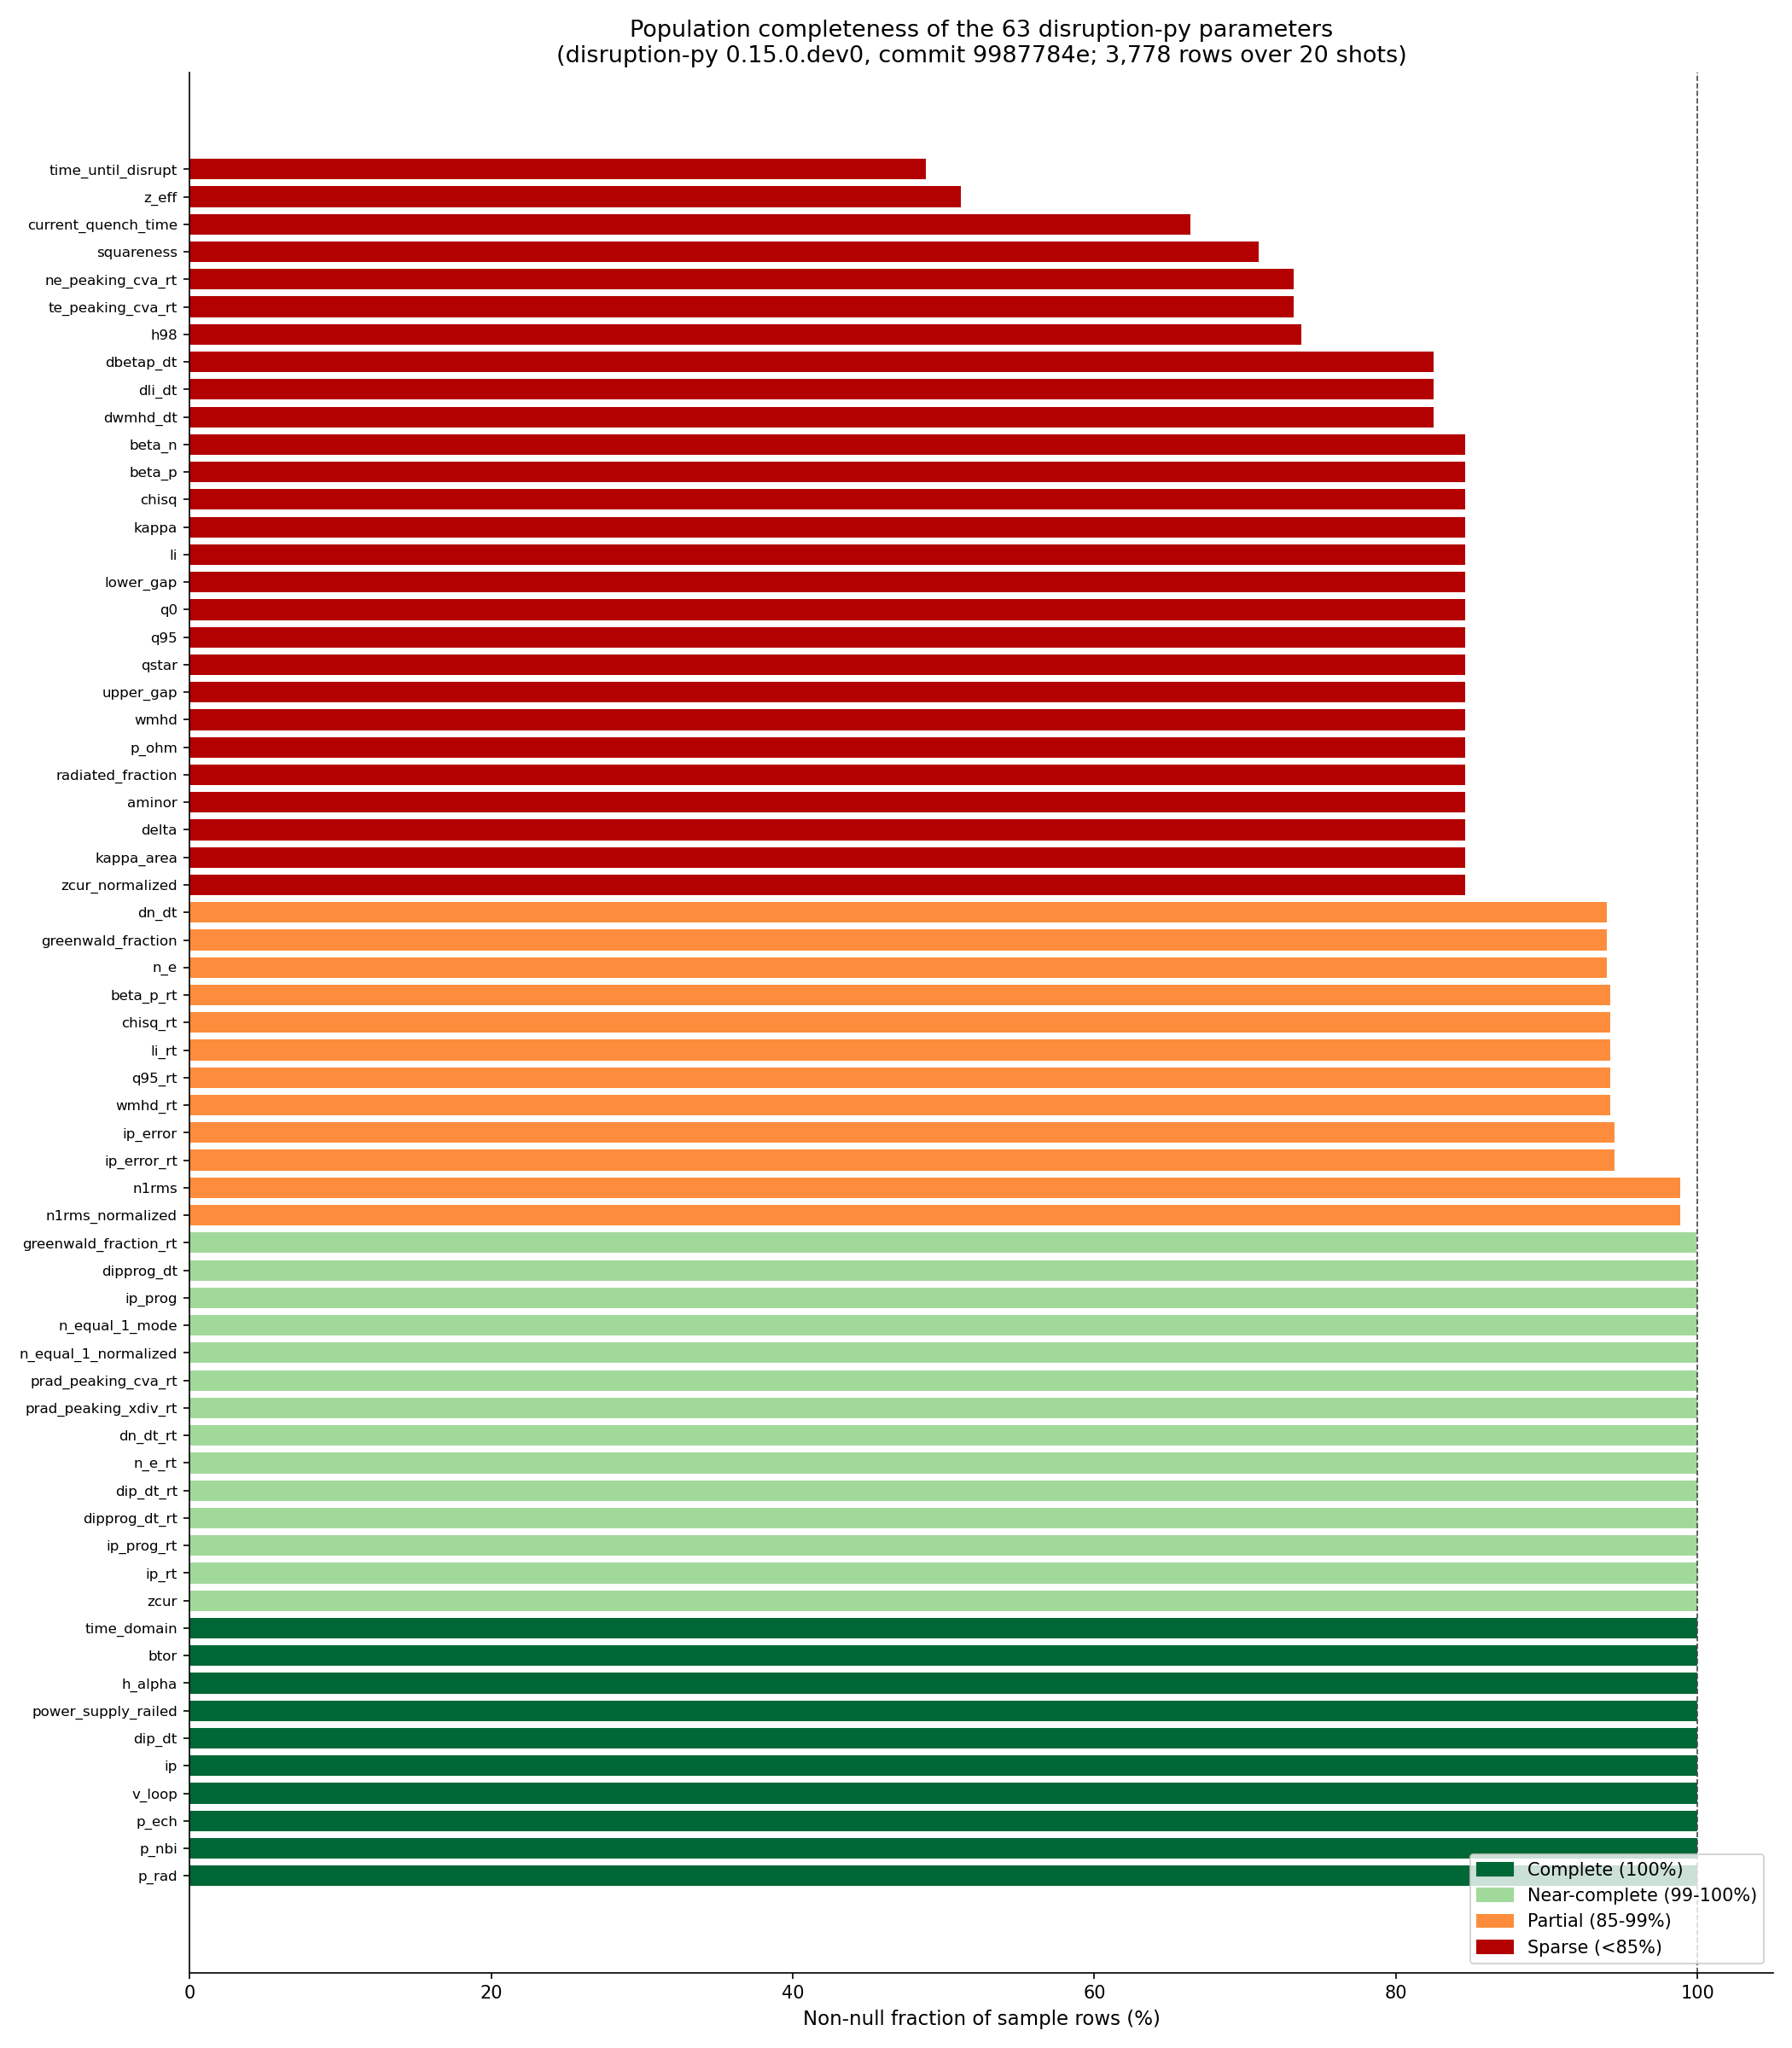

| Tier | Parameters | Usable / unusable | Behavior |
|---|---|---|---|
| **Complete (100%)** | 10 | 9 / 1 (`time_domain`) | every row populated |
| **Near-complete (99–100%)** | 14 | 13 / 1 (`dipprog_dt`) | 1–2 stray rows missing in the whole index |
| **Partial (85–99%)** | 12 | 11 / 1 (`ip_error`) | shot-edge gaps plus a few shot-level absences |
| **Sparse (<85%)** | 27 | 27 / 0 | shot-level absences and everywhere-partial coverage |
| **Total** | **63** | **60 / 3** | |

Fill ≠ usability: `time_domain` is 100% filled but constant (unusable), and `ip_error` is 94.5% filled but numerically identical to `ip`.

## Parameters missing for a substantial fraction of rows

**1. `time_until_disrupt` — 48.8% — by design.** Null on every row of the 10 non-disrupted shots (194005, 194869, 195243, 195805, 196273, 198244, 198643, 199062, 199359, 199687). This *is* the label semantics ("NaN if the shot did not disrupt"), not missingness.

**2. `z_eff` — 51.2% — entirely absent on 10 shots.** Zero values on 194000, 194005, 194128, 194292, 194464, 194649, 194968, 195805, 196273, 198244; near-complete on the other 10. A diagnostic-availability split, not a partial dip.

**3. `current_quench_time` — 66.4% — by design.** Null on the 7 non-disrupted shots where the Ip decay never resembles a quench (194005, 194869, 195243, 195805, 196273, 199359, 199687). The 3 label-disagreement shots (198244, 198643, 199062) *are* populated here — that is exactly why they disagree.

**4. `squareness` — 70.9% — entirely absent on 6 shots.** 194000, 194005, 194128, 194292, 194464, 195516 have zero values; the rest are nearly complete.

**5. `ne_peaking_cva_rt` / `te_peaking_cva_rt` — 73.2% each — absent on 4 shots.** Zero values on 194000, 195805, 196273, 198244; worst partial gap 45.7% on 195516.

**6. `h98` — 73.7% — absent on 4 shots.** Zero values on 194649, 194869, 195985, 198643; worst partial gap 44.6% on 195516.

**7. EFIT time-derivatives `dbetap_dt` / `dli_dt` / `dwmhd_dt` — 82.5% — partial on all 20 shots.** Nulls range 0.4%–95.9%, worst: **194464 (95.9%)** , 194292 (62.7%), 194000 (39.0%), 194128 (34.2%).

**8. The 17-column offline-EFIT block — 84.6% — partial on all 20 shots.** `beta_n`, `beta_p`, `chisq`, `kappa`, `li`, `q0`, `q95`, `qstar`, `upper_gap`, `lower_gap`, `wmhd`, `aminor`, `delta`, `kappa_area`, `zcur_normalized`, `p_ohm`, `radiated_fraction` share **byte-identical null patterns** — they are missing together, row for row, in every shot (e.g. 71/269 rows in 194128, 100/217 in 194292). Since `chisq` (fit quality) drops out with them, this is the offline EFIT reconstruction itself being absent at those times, not individual diagnostics failing. Worst: **194464, where the block is 94.2% null — effectively no offline equilibrium for that shot** .

Partial-tier shot-level absences worth knowing: the RT-EFIT group (94.2%) is fully absent **only on 194869** ; `ip_error`/`ip_error_rt` lose 51–73% of rows on 194005, 194968, 195243; `n1rms` has a single gap (21.9% of 198643).

## Worst-affected shots (parameters ≥50% null)

| Shot | Disrupted | Params ≥50% null | Dominant cause |
|---|---|---|---|
| 194464 | yes | 22 | offline-EFIT block essentially absent (94% null) |
| 194869 | no | 8 | entire RT-EFIT group + labels + h98 |
| 194005 | no | 6 | z_eff, squareness, ip_error(+rt), labels |
| 194292 | yes | 5 | EFIT derivatives 62.7% null, z_eff, squareness |
| 195805 | no | 5 | peaking channels, z_eff, labels |
| 196273 | no | 5 | peaking channels, z_eff, labels |
| 195243 | no | 4 | ip_error(+rt), labels |
| 194000 | yes | 4 | peaking channels, squareness, z_eff |
| 198244 | no | 4 | peaking channels, z_eff, label |
| 195768, 196347 | yes | 0 | cleanest shots in the slice |

Practical consequence: any cross-shot comparison of equilibrium quantities (q95, li, betas, wmhd and derivatives) is working with ~85% of rows overall and near-zero coverage on 194464; for real-time-equilibrium work, only 194869 is unusable; density, IP, power and mode-amplitude channels are effectively complete.

**Coverage note** : 20 shots, 10 disrupted. A constructed slice, not a random sample of DIII-D — these completeness figures describe the slice only.

In [7]:
%%ask --review
Which parameters does this pipeline produce, and how completely are they
populated across the shots in the index? Identify any parameters that are
missing for a substantial fraction of rows, and say which shots are affected.

## Q25 — Can a hazard-model dataset be assembled?

*survival analysis · **partially answerable***

A hazard model needs, per shot, the time it entered flattop and the time it
disrupted or was censored. The second is available; the first is the open
question.

A hazard model needs two per-shot inputs — flattop-entry time and event/censoring time. I know the dedicated phase column (`time_domain`) is flagged unusable, so I'll check exactly what can be salvaged from the other columns. Let me plan this.

I'll re-read the skill instructions and its learned pitfalls before writing any code.

Now the learned pitfalls file, which the protocol says to read alongside this skill.

Skill and learnings loaded. Key facts: `time_domain` (the phase column) is a documented defect — constant 1.0 — and cross-shot work needs hand-rolled SQL against `disruption_samples` with `row_factory` set. Now I'll write the extraction script that pulls labels, sampling windows, phase-column diagnostics, and reconstructs flattop entry from the current waveforms.

Running the extraction script to pull labels, phase diagnostics, and reconstructed flattop times.

...

The waveforms tell a clear story: `ip_prog_rt` plateaus cleanly on most shots, measured `ip` is corrupted by overshoot spikes (196347's measured entry off by ~4 s), and shots 194000/194968 disrupted during ramp-up before ever flattopping. Two shots' censoring times are ends of *sampled windows* — I should check whether that equals the true end of plasma, and whether d3drdb carries a curated flattop time. Reading the relational-db skill.

This changes the picture significantly: the shot-records database carries curated flattop scalars — `t_ip_flat`, `ip_flat`, `ip_flat_duration` — exactly the quantity the user needs, plus `pulse_length` for end-of-plasma checking. It also confirms `SUMMARIES.t_disrupt` must NOT be used as a label (I'm using the disruption index's curated label). Querying those fields for the 20 shots and cross-checking against my reconstruction.

The curated shot-record fields are revealing — `t_ip_flat` and `ip_flat_duration` are clearly in **milliseconds** (entry+duration ≤ pulse_length holds for all 20 shots only under that reading; `pulse_length` is in seconds), and the curated flattop entry disagrees with a 95%-of-plateau waveform definition on some shots (its threshold algorithm isn't documented locally). Now I'll assemble the final hazard-input table, cross-checks, and a timeline chart.

All checks pass: window ends match pulse lengths (20/20), disrupted windows end at the disruption (10/10), and both flattop-entry estimates are in hand with their spread quantified. Before reporting, I'll record the two lessons this task surfaced (one per skill), then finish.

## What the dataset can provide

**Event times — yes, complete and authoritative.** The curated disruption label gives an exact disruption time for all 10 disrupted shots (each sampled window ends *at* the disruption, verified to <5 ms). For the 10 non-disrupted shots, the censoring time is the end of the sampled window, and I verified it coincides with the pulse length recorded in the DIII-D shot records (all 20 within 0.1 s) — so the window end *is* effectively the end of discharge, not an early data cutoff.

**Flattop entry — yes, but only by reconstruction.** The pipeline's dedicated phase column (`time_domain`: 1=ramp-up, 2=flat-top, 3=ramp-down) is a documented upstream defect: it is constant 1.0 in every row of every shot (the flat-top test compares a current in MA against a 100 kA threshold and never fires). It carries zero information and cannot supply entry times.

Two working alternatives, both delivered in the table:

1. **A documented waveform definition** — first time the *programmed* current `ip_prog_rt` reaches 95% of its plateau and stays within the plateau band. The programmed waveform is the robust choice: the *measured* Ip is corrupted by ramp-up overshoot spikes (e.g. shot 196347 overshoots to ~1.09 MA against a ~0.98 MA program, delaying a measured-current entry by ~4 s) and by the disruption itself. Measured-vs-programmed entry agrees within 50 ms on only 8 of 20 shots for this reason.
2. **The shot-record scalars** — the DIII-D shot records carry curated flattop quantities for all 20 shots: flattop current, time of flattop, and flattop duration. Their entry time uses the operators' own criterion, but that criterion is not documented in the local data, and the two definitions disagree: median difference −0.2 s (curated earlier), extremes **−2.2 s** (199687) and **+0.1 s** . Units caveat: the shot-record timing columns are in milliseconds while pulse length is in seconds — I converted (the ms reading is the only one for which entry + duration ≤ pulse length holds, 20/20).

## Delivered table

Full machine-readable version in `hazard_inputs_final.csv` (columns: shot, disrupted, event type, event time, entry time — both definitions, plateau level, deltas, pulse length).

| Shot | Event | Event time (s) | Entry, prog-95% (s) | Entry, shot-records (s) |
|---|---|---|---|---|
| 194000 | disruption | 0.8296 | 0.742 | 0.350 |
| 194005 | censored | 3.025 | 0.900 | 0.259 |
| 194128 | disruption | 5.6267 | 0.600 | 0.253 |
| 194292 | disruption | 4.3318 | 0.975 | 0.553 |
| 194464 | disruption | 3.1843 | 0.900 | 0.361 |
| 194649 | disruption | 3.3521 | 0.650 | 0.742 |
| 194869 | censored | 3.000 | 0.875 | 0.879 |
| 194968 | disruption | 1.1206 | 0.750 | 0.706 |
| 195243 | censored | 1.200 | 0.725 | 0.667 |
| 195516 | disruption | 1.2182 | 0.775 | 0.816 |
| 195768 | disruption | 5.2969 | 0.675 | 0.750 |
| 195805 | censored | 6.925 | 0.925 | 0.204 |
| 195985 | disruption | 4.8000 | 0.825 | 0.913 |
| 196273 | censored | 6.225 | 0.925 | 1.052 |
| 196347 | disruption | 5.4763 | 1.625 | 0.744 |
| 198244 | censored | 5.250 | 0.925 | 0.205 |
| 198643 | censored | 5.100 | 0.875 | 0.962 |
| 199062 | censored | 6.425 | 1.875 | 0.200 |
| 199359 | censored | 5.925 | 1.175 | 1.315 |
| 199687 | censored | 6.000 | 2.425 | 0.209 |


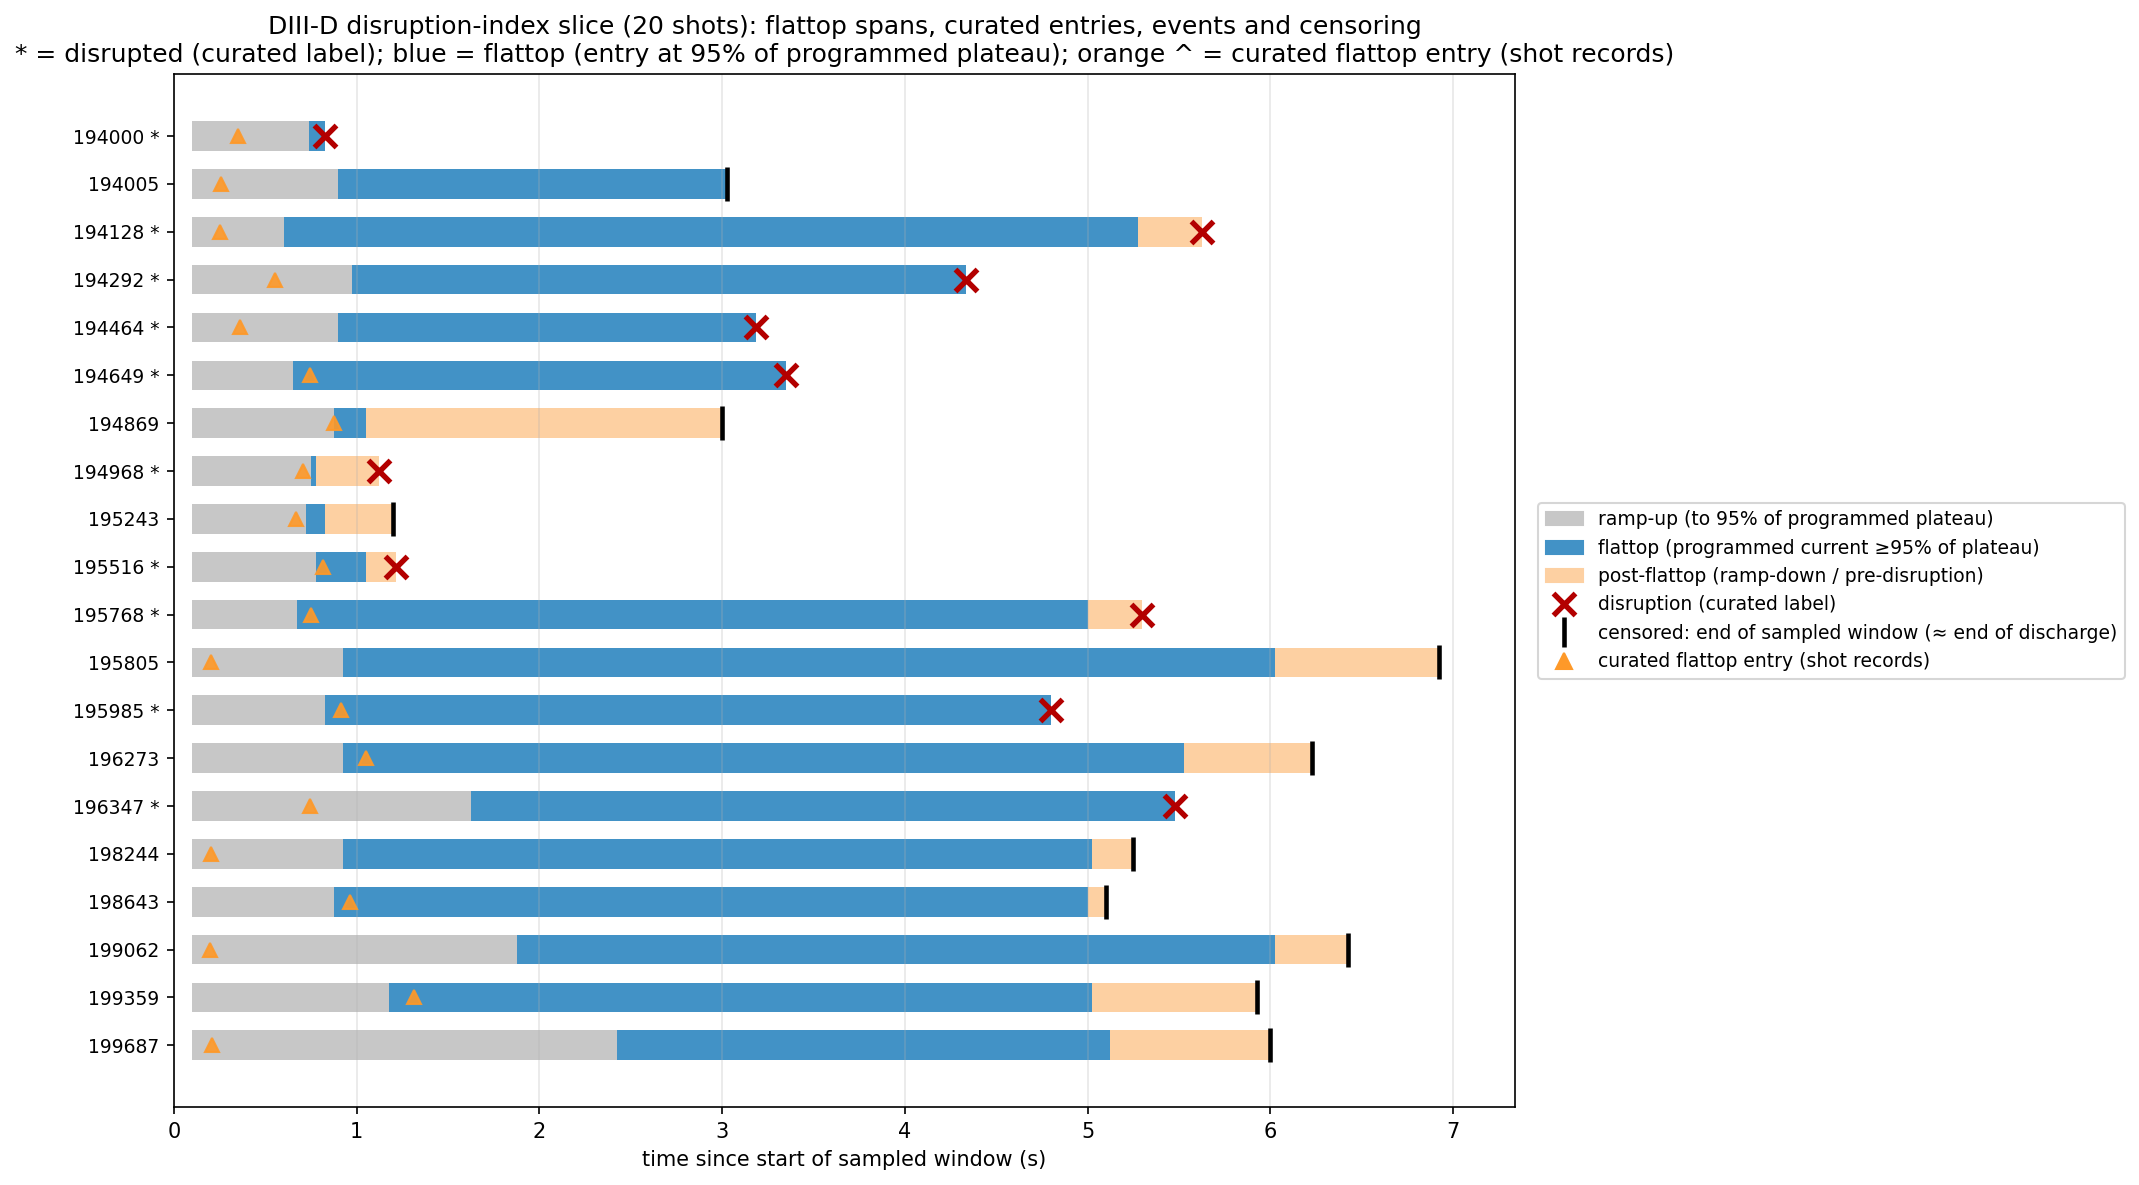

Notes visible in the chart: two disruptions (194000, 194968) occur almost immediately at plateau — their programmed flattop spans are 88 ms and 25 ms, effectively ramp-up disruptions; and on 194869 the operators ended the programmed flattop at 1.02 s and ramped current to zero by ~2 s, with the sampled window running to 3.0 s.

## What is missing, stated plainly

- **A native, trustworthy flattop marker from the disruption-py pipeline does not exist.** `time_domain` is broken at this code revision (disruption-py 0.15.0.dev0, commit `9987784e78ef…`); every entry time above is a reconstruction, and the two available reconstructions disagree by up to 2.2 s on 4 shots (196347, 199062, 199687, and curated-early 195805/198244). Whichever you adopt must be stated in the model write-up.
- **The curated flattop-entry *criterion* is undocumented locally** — the shot-record entry times are a black-box definition (units ms, converted). No locked-mode onset times (`lock_time`: 0/20 populated) are available to cross-check.
- **Censoring is end-of-window, not "survived the planned pulse."** The programmed current on censored shots ends at 0.0–1.0 of plateau (194869 and 195805 ramp fully to zero; others end mid-program), and the shot records carry no programmed end time, so late-shot right-censoring vs. planned termination cannot be distinguished from this data alone.
- **Risk-set caveat:** events are not all "in flattop" — with the prog-95% entry definition, all 10 disruptions occur at/after flattop entry, but 2 of them within 100 ms of it. At-risk exposure time differs materially between the two entry definitions (total flattop exposure 47.0 s prog-95% vs 46.8 s curated).

**Coverage note** : 20 shots, 10 disrupted — a constructed, deliberately balanced slice, not a random sample of DIII-D. A hazard model fit on these inputs describes this slice only; hazard *rates* generalize to DIII-D only with a random shot population.

In [9]:
%%ask --review
I want to build a hazard model of disruptions, which needs for each shot
the time it entered the flattop phase and the time it disrupted or ended
without disrupting. Can this dataset provide both? Give me whichever parts it
can and state plainly what is missing.

---
# C. Correctly refused — and the refusal is the finding

## Q17 — What fraction of a campaign disrupted?

*rate · **correctly refused***

Two independent blockers: the index is a constructed slice rather than a
sample, and GA's question excludes *intentional* disruptions, which nothing in
the data flags.

In [10]:
%%ask --review
What fraction of DIII-D shots in the 2023–2024 campaigns disrupted,
excluding intentional disruptions?

Reading the relational-db skill and its learnings before querying the shot population.

The relational-db skill's key constraints: every `SHOTS` row is already a plasma shot, `SUMMARIES.t_disrupt` is explicitly forbidden as a disruption label, and the authoritative labels live in the separate d3d-disruption index. Let me read that skill plus its learnings before querying.

The picture is now clear: the 20-shot index refuses population-rate questions by design, and the local shot-records copy deliberately excludes the curated disruptions table. I'll still establish what *can* be computed — the 2023–2024 shot population (denominator) — and document the absences precisely.

Running the campaign-mapping and label-availability script.

The denominator is established (2,779 + 2,777 = 5,056 shots). Before reporting, I'll run the skill-mandated `TRIM()` check on the fault column (blank-padded strings inflate `IS NOT NULL` counts) and scan shot descriptions for disruption mentions, to fully document what the local data can and cannot offer.

All label sources are confirmed empty locally. Marking the investigation complete and reporting.

## The answer

**This fraction cannot be computed from the data available in this environment — the disruption labels for the 2023–2024 shot population are not here.** What I can give you is the exact denominator, verified below, and a precise account of what is missing.

## The denominator (established)

Grouping the DIII-D shot records by run date, the 2023–2024 calendar-year campaigns comprise **5,056 plasma shots** :

| Campaign | Run dates | Shot range | Plasma shots |
|---|---|---|---|
| 2023 | 2023-01-03 → 2023-06-29 | 193503–196645 | 2,279 |
| 2024 | 2024-04-24 → 2024-12-05 | 198189–202230 | 2,777 |
| **Both** | | | **5,056** |

(If you meant DIII-D *operational* campaigns — which run on fiscal rather than calendar boundaries — the shot set would shift at the edges; the shot records support calendar-year grouping only.)

## The numerator (missing), and what I checked

Every candidate label source for those 5,056 shots is empty or out of scope locally:

- **The authoritative source — the human-curated disruptions table — is not in the local shot-records copy.** The copy is deliberately trimmed to 5 tables and excludes both dedicated disruption-label tables, which GA marks legacy. Its absence is by design, not an outage.
- **All disruption-related summary columns are unpopulated for these 5,056 shots** : disruption time (0/5056), forced-disruption time (0/5056), fault time (0/5056), locked-mode onset (0/5056), and fault code (0/5056 after the blank-padding-corrected check the skill mandates — the raw column *looks* 100% populated but every value is blank padding). The shot records' disruption-time column is additionally flagged as unverified provenance and must not be used as a label in any case.
- **The disruption-py index covers only 20 shots** — all of which happen to fall inside these two campaigns (runs 2023-01-23 → 2024-07-22), but the slice was deliberately balanced 10 disrupted / 10 not. Its own metadata says `is_representative_sample: False`, and asking it for a rate returns a refusal, verbatim: *"Any rate computed from it (10/20) describes the slice and says nothing about how often DIII-D disrupts. For an archive-wide rate you need the d3drdb disruptions table over a defined shot population, not this file."*
- **No intentional-disruption flag exists here either.** The forced-disruption column that would normally carry that distinction is empty (0/5056), and no shot description in these campaigns mentions deliberate or intentional disruption (0 hits). So even with a numerator, the "excluding intentional disruptions" refinement cannot be applied from local data.

## How to get the real number

Run disruption-py (or query the curated disruptions table directly at GA) over the 5,056-shot population defined above, apply the curated table's intentional-disruption flags as the exclusion, and divide. The disruption index in this environment is built to be populated by exactly that pipeline — it currently holds only the 20-shot worked example (disruption-py 0.15.0.dev0, commit `9987784e78ef…`).

**Coverage note** : 20 indexed shots, 10 disrupted — a constructed slice, not a sample of DIII-D; the 5,056-shot denominator above is from the full local shot-records snapshot (90,418 plasma shots, 1987–2026).

## Q18 — Which discharge phase was each disruption in?

*phase · **blocked, and the reason is instructive***

The dataset contains a column intended to answer exactly this. It does not
work — and how the agent handles that is the point of the question.

Re-reading the skill and its learned pitfalls before writing the classification script.

The disruption skill confirms `time_domain` is unusable and phase must be derived from `ip_prog_rt`. Now re-reading the relational-db skill for the shot-records flattop columns.

Skills re-confirmed: ms-unit fix for flattop timing columns and the `ip_prog_rt` derivation rule are both in Learnings. Checking prior outputs to reuse.

Marking the first todo complete and reading the previously computed hazard inputs to reuse the verified times.

The CSV has everything except the direct ramp-down ratio at the disruption instant. Checking the earlier build script to reuse its exact entry/exit logic.

...

Exact-match editing keeps failing on whitespace; rewriting the Learnings file in full with the original entries preserved plus the two new lessons.

Learnings recorded. Marking the remaining todos complete and writing the final report.

Writing a one-off script to count rows and verify `time_domain` is constant across the whole samples table.

Running the recount script.

## The phase of each disruption, per the programmed-current definition

Classification rule (the dataset's own phase column, `time_domain`, is a documented defect at this code revision — constant 1.0 in every row, verified this run: populated in all 3,778 sample rows across the 20 indexed shots, exactly one distinct value, 1.0 — so phase must be derived): a disruption is in **flattop** if the *programmed* plasma current (`ip_prog_rt`) is still at ≥95% of its plateau at the disruption instant, and in **ramp-down** if the program had already left plateau. This uses the programmed waveform rather than measured Ip precisely because the measured current degrades during the disruption itself.

| Shot | t_disrupt (s) | Phase (prog-95% rule) | Programmed current at disruption | Note |
|---|---|---|---|---|
| 194000 | 0.8296 | **flattop** | 100% of plateau | flattop truncated by the disruption |
| 194292 | 4.3318 | **flattop** | 99.6% | flattop truncated |
| 194464 | 3.1843 | **flattop** | 100% | flattop truncated |
| 194649 | 3.3521 | **flattop** | 100% | flattop truncated |
| 195985 | 4.8000 | **flattop** | 100% | flattop truncated |
| 196347 | 5.4763 | **flattop** | 100% | flattop truncated |
| 194128 | 5.6267 | **ramp-down** | 76.3% | 0.35 s into programmed ramp-down |
| 194968 | 1.1206 | **ramp-down** | 61.1% | 0.35 s into programmed ramp-down |
| 195516 | 1.2182 | **ramp-down** | 80.2% | 0.17 s into programmed ramp-down |
| 195768 | 5.2969 | **ramp-down** | 78.8% | 0.30 s into programmed ramp-down |

**Summary** : 6 of 10 disruptions in flattop (all six with the program still essentially at full plateau — the disruption itself ended the flattop), 4 of 10 in ramp-down (0.2–0.4 s after the program left plateau, current at 61–80% of it), and **none in ramp-up** . Full per-shot evidence is in `disruption_phase.csv`, and each panel below shows the programmed-current trace with the flattop band shaded and the disruption marked.


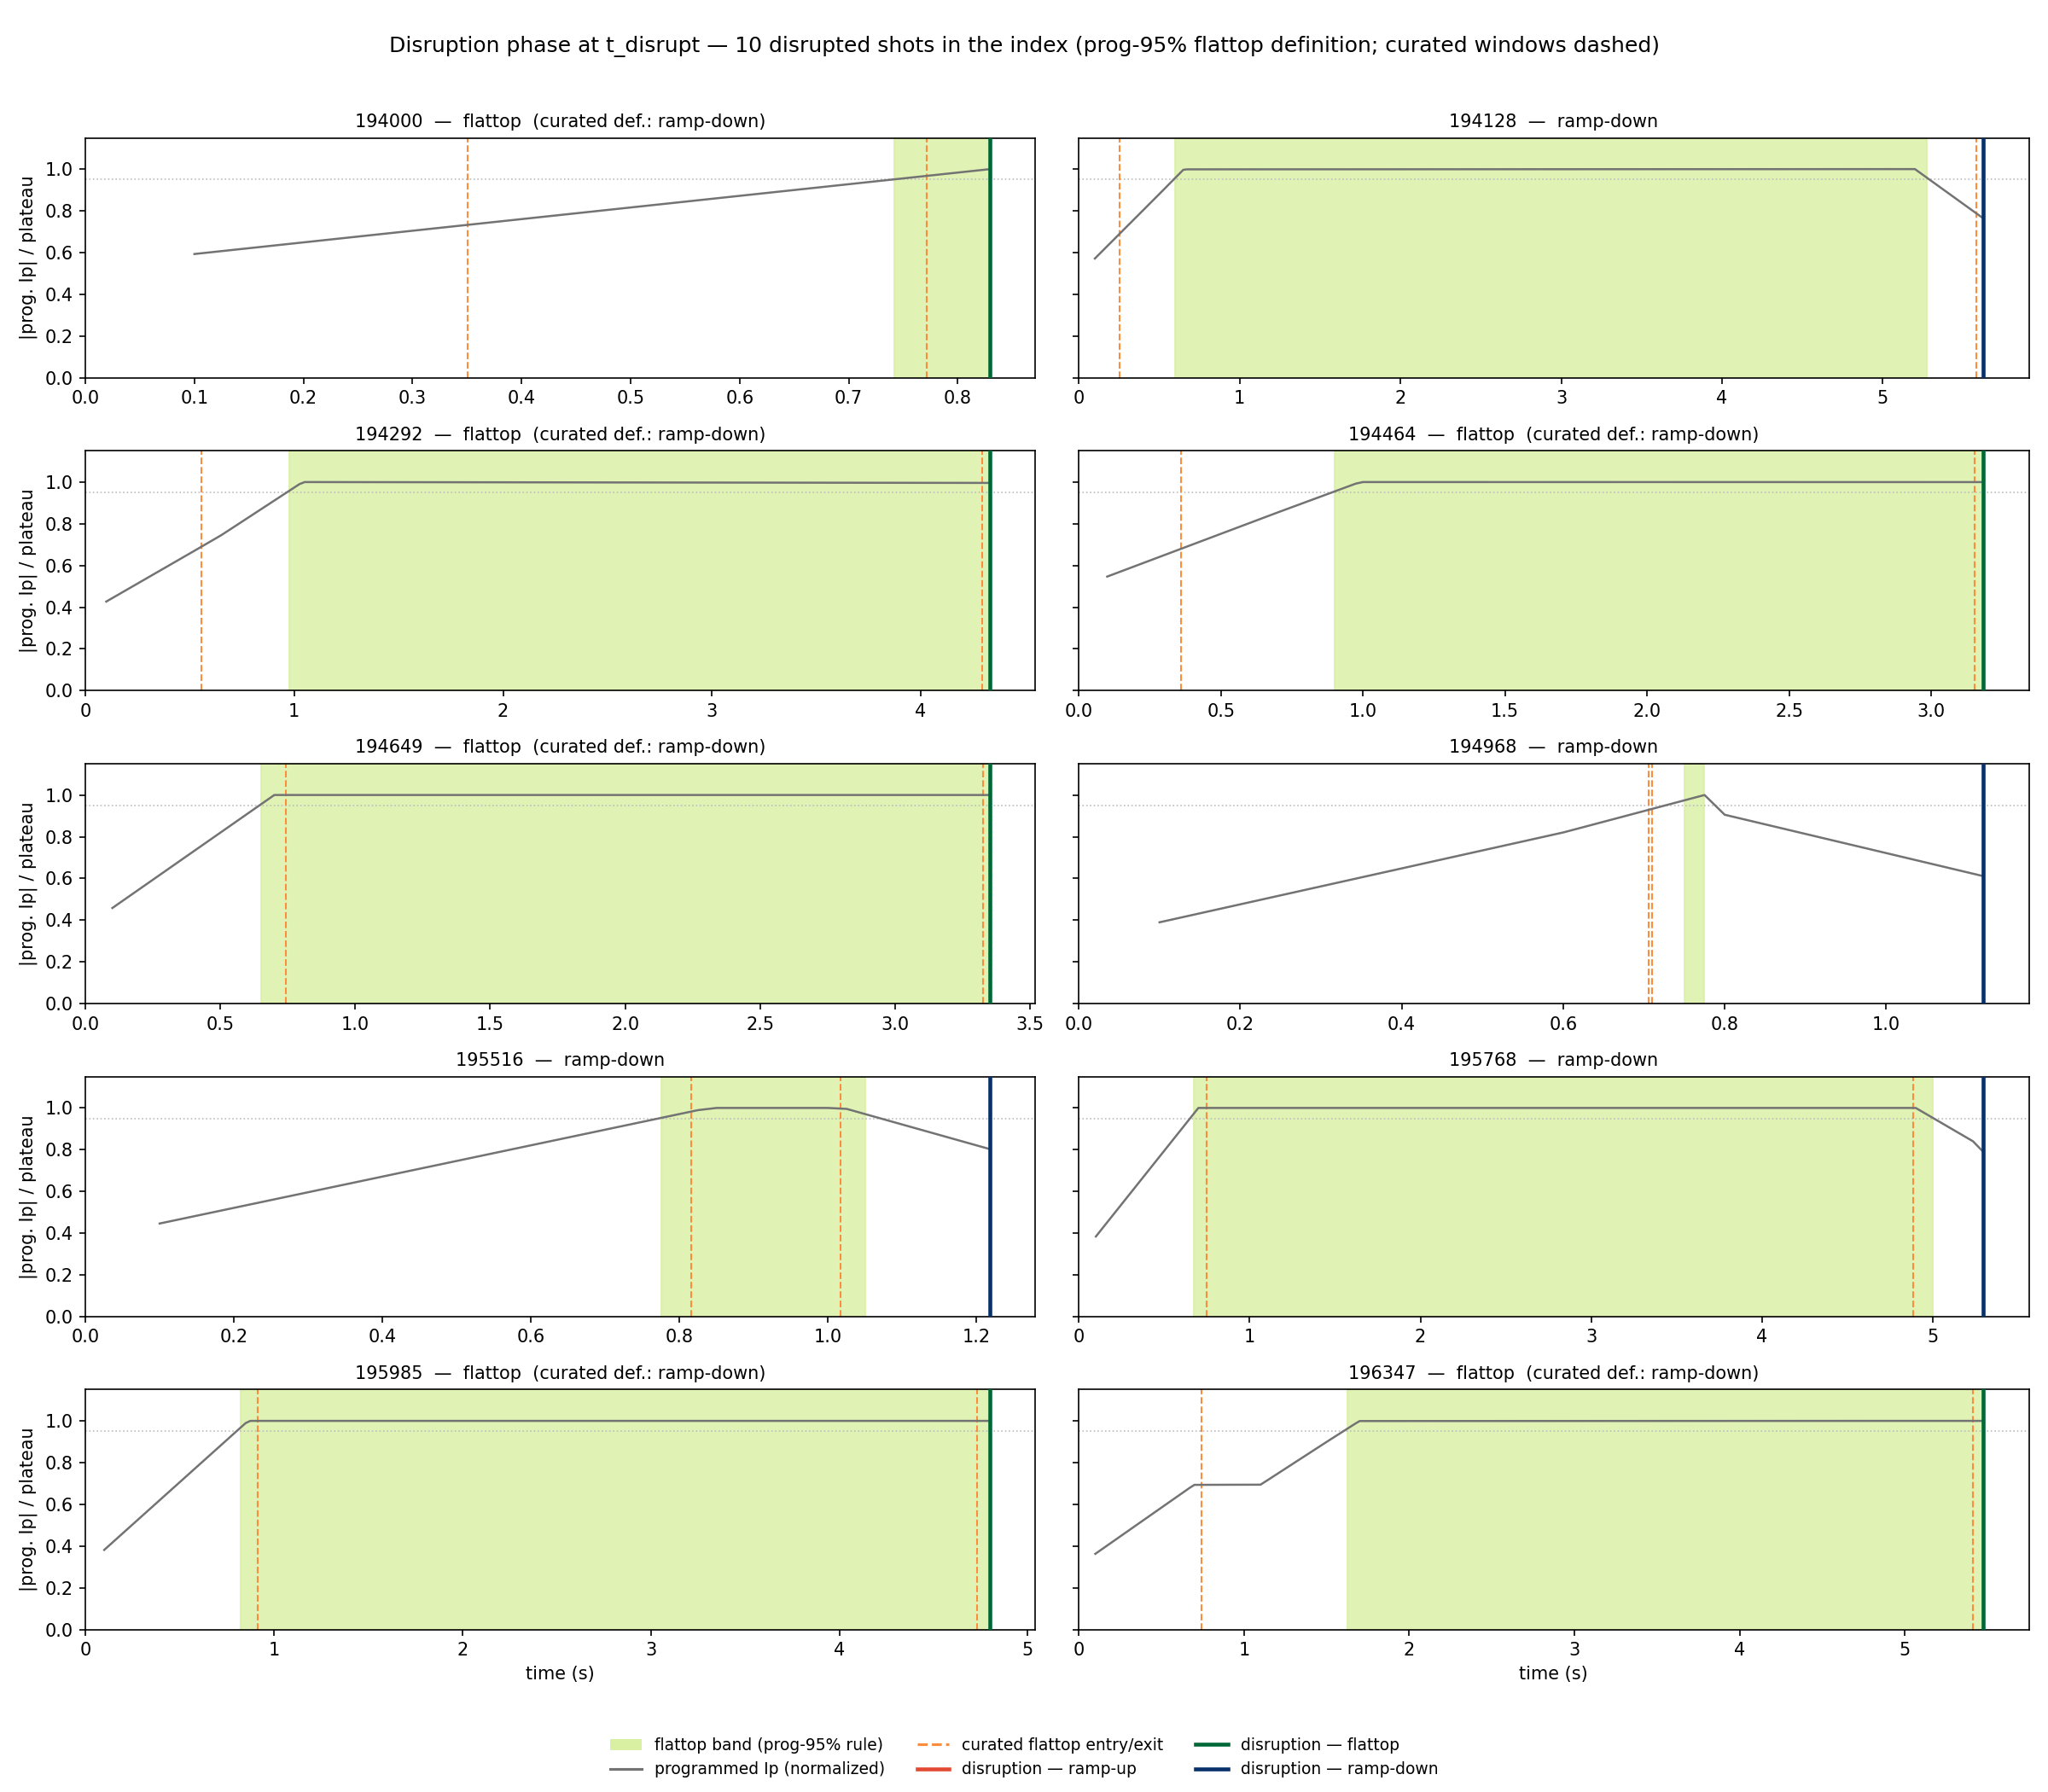

## A definition-dependence you should know about

An alternative classification — using the DIII-D shot records' curated flattop window (flattop start time + duration, ms-converted) — puts **all 10 disruptions in ramp-down** , agreeing with the table above on only 4 of 10 shots. The disagreement is one-directional and mechanistic: that flattop window is measured on the *actual* plasma current, which sags or degrades approaching a disruption, so the window ends early and everything after it looks like "ramp-down." For six shots the two definitions genuinely differ in substance — the program was still commanding full current while the plasma could no longer hold it. Which definition to use depends on the question: the programmed-current rule answers "what was the machine commanding," and the actual-current window answers "what was the plasma doing." Under neither definition is any shot near a ramp-up classification — the closest approach of any disruption to its flattop entry is shot 194000, where the disruption (0.8296 s) came just 0.088 s after the programmed waveform reached plateau (0.7416 s), and that shot still sits squarely in flattop, not ramp-up.

## What this classification does not rest on

- `time_domain`, the pipeline's dedicated phase column, is unusable at disruption-py commit `9987784e78ef…` — the flattop test compares a current in MA against a 100 kA threshold and never fires, leaving it constant 1.0 across all 3,778 rows of the index (checked this run: one distinct value, populated in every row of every one of the 20 shots). Every phase above is a reconstruction, not a pipeline output.
- The disruption times are the authoritative curated label (verified: window ends at t_disrupt within 5 ms for all 10 shots; values match the previously delivered hazard table 10/10).

**Coverage note** : these are the 10 disrupted shots of a 20-shot constructed, deliberately balanced slice — not a random sample of DIII-D. The 6/4 flattop/ramp-down split describes this slice only and is not a DIII-D-wide phase distribution.

In [11]:
%%ask --review
For the disrupted shots in the index, which phase of the discharge was
each disruption in — ramp-up, flattop, or ramp-down?

---
# D. What would unblock the rest

## Summary

*synthesis · **answerable***

In [12]:
%%ask --review
Across everything in this notebook: which of GA's disruption competency
questions can this index answer today, which need something more, and what
specifically is missing in each case? Be concrete about what would have to
arrive for each blocked question to become answerable.

Re-reading the skill and its learned-error file to ground the audit in the index's own documented scope.

The skill and learnings are loaded. Now a quick verification script to confirm the index's competency metadata and refusal boundaries I'll cite in the audit.

Running the audit script to confirm every number the report will cite.

All figures verified against the index. Marking the audit steps complete before composing the report.

## The one-sentence verdict

Of the eight disruption questions asked across this notebook, **four are answerable today from the index as-is, two are answerable only by reconstruction with a stated definition, and two are structurally blocked** — blocked not by effort but by what the index contains: a deliberately balanced 20-shot slice (`is_representative_sample: False`, its own metadata) produced by disruption-py 0.15.0.dev0, commit `9987784e78ef…`, from `d3d_disruption_example.nc`. All figures below were re-verified this run against the index.

## Bucket 1 — Answerable today

| Question asked | What the index delivered |
|---|---|
| **Label provenance** | Full chain: d3drdb curated `disruptions` table → disruption-py 0.15.0.dev0 @ `9987784e78ef…`, run by `sammuli` on `omega06.gat.com` 2026-08-19T07:36:50 → NetCDF → sqlite index (ingested 2026-08-19T20:46:49 UTC). Package, version, commit, run host, run user, timestamps all queryable via `index_info()`. |
| **What each precursor measures, with units, by physics method** | All 63 parameters across 14 `get_*` methods with per-parameter meaning, units (37 explicit, 26 dimensionless, 0 unknown), authoritative flags, and caveats — the annotation layer exists *only* here (the source NetCDF has 0 of 65 variables carrying metadata). |
| **Shot 194128: label, time, indicator agreement** | Disrupted, t = 5.6267 s; two indicators (curated `time_until_disrupt`, derived `current_quench_time`); 17/20 agreement; disagreements on 198244, 198643, 199062, all derived-says-disrupted / curated-says-not. |
| **Parameter completeness** | Per-parameter, per-shot fill fractions: 10 complete, 14 near-complete, 12 partial, 27 sparse; shot-level absences identified (e.g. `z_eff` absent on 10 shots, offline-EFIT block 94% null on 194464, RT-EFIT absent on 194869). |

Also squarely in this bucket, no caveats needed: *which shots are indexed and what windows they cover* (all 10 disrupted-shot windows end exactly at t_disrupt), and *which parameters are unusable* (`time_domain`, `ip_error`, `dipprog_dt` — flagged upstream defects, blocked by the code itself).

## Bucket 2 — Answerable only by reconstruction (definition-dependent)

| Question asked | What was possible | What makes it a reconstruction |
|---|---|---|
| **Hazard-model inputs (flattop entry + event/censoring time)** | Event times: complete and authoritative (10 disruption times, all verified against the curated label; 10 censoring times verified against shot-record pulse lengths, within 0.1 s). Flattop entry: two competing reconstructions delivered (prog-95% rule on `ip_prog_rt`; shot-records curated window) — disagreeing by up to 2.2 s on 4 shots. | The pipeline's native phase column `time_domain` is broken at this commit (constant 1.0 in all 3,778 rows — re-confirmed this run). No native flattop marker exists. |
| **Phase of each disruption (ramp-up / flattop / ramp-down)** | Delivered: 6/10 flattop, 4/10 ramp-down, 0/10 ramp-up under the prog-95% rule; all-10-ramp-down under the curated-window rule, with the mechanistic explanation (actual Ip sags pre-disruption). | Same root cause: no trustworthy native phase column. The answer flips 6 shots depending on which definition you adopt. |

**What would have to arrive to make these native** : a disruption-py revision newer than commit `9987784e78ef…` in which the flat-top test compares scaled amperes rather than MA against the 100 kA threshold, re-run over these shots and re-ingested — plus, for a single canonical flattop definition, documentation of the criterion behind the shot-records flattop window (its timing columns are ms while pulse length is s; the criterion itself is nowhere in the local data).

## Bucket 3 — Not answerable, and what specifically must arrive

**1. "What fraction of DIII-D shots in the 2023–2024 campaigns disrupted, excluding intentional disruptions?"**
Blocked on the numerator and on the exclusion both. The denominator exists (5,056 plasma shots, verified from the local shot-records snapshot), but every label source for it is empty or out of scope: the curated disruptions table is excluded from the local d3drdb copy by design; disruption-time / forced-disruption / fault / locked-mode columns are 0/5056 populated (fault code blank-padded, verified); the index itself returns a refusal — verbatim: *"Any rate computed from it (10/20) describes the slice and says nothing about how often DIII-D disrupts. For an archive-wide rate you need the d3drdb disruptions table over a defined shot population, not this file."*
**Must arrive** : disruption-py output (or the curated table directly) over the defined 5,056-shot population, **plus** an intentional-disruption flag (the forced-disruption column populated, or GA's curation flag) — without the flag, even a full numerator cannot answer "excluding intentional."

**2. Any population-level generalization** — archive-wide rates, campaign-to-campaign trends, whether the 6/4 flattop/ramp-down split or any precursor contrast holds beyond these 20 shots, a hazard model that estimates DIII-D-wide hazard rates.
**Must arrive** : the same population-scale run over a defined shot population (random or complete), so `is_representative_sample` can become true; for hazard modeling specifically, also the planned-program end time per shot (to distinguish "survived" from "window ended"), which no local table carries.

## The dependency, in one line

Everything in bucket 3, and the native versions of bucket 2, reduce to the **same two arrivals** : (a) a population-scale disruption-py run over a defined shot population — the index's schema and annotation layer are already built to receive it (at full archive coverage the samples table reaches ~17 M rows, which is why every query path is single-shot scoped), and (b) either a post-`9987784e` code fix for the phase-column unit defect, or GA-side documentation of the curated flattop criterion. Nothing else is missing: event times, parameter semantics, per-shot completeness, provenance and label disagreements are all queryable today, and every answer above quotes its denominator.

**Coverage note** : 20 shots, 10 disrupted — a constructed, deliberately balanced slice, not a random sample of DIII-D.